# 04 — Module 3: Dormancy vs. Death (Competing Risks)

Distinguishes creators who go silent and come back (dormant) from those who go silent and don't (departed, as observed within the window) — something a standard survival model can't do, because it treats all silence as the same "censored" event.

**A labeling bug I caught here:** my first attempt at competing-risk labels checked "is there an episode after this gap in the array" to decide recovery — but *any* gap in that array is, by definition, followed by an episode (that's what makes it a completed gap). Every long gap registered as "recovered," and the "no recovery" category came out completely empty. The fix: append a virtual checkpoint at the snapshot date so the trailing, *incomplete* gap — the actual "no recovery observed" case — gets checked too.

In [1]:
import sys
sys.path.insert(0, "..")
import json
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter

with open("../outputs/module3_metrics.json") as f:
    m3 = json.load(f)

features = pd.read_parquet("../data/processed/features.parquet")
labels = pd.read_parquet("../data/processed/competing_risk_labels.parquet")
df = features.merge(labels, on="podcast_id")

print(f"{m3['cif']['n_recovered']:,} recovered, {m3['cif']['n_no_recovery']:,} no recovery observed, {m3['cif']['n_censored']:,} censored")
print(f"Recovery rate: monetized={m3['cif']['recovery_rate_monetized']:.1%}, not monetized={m3['cif']['recovery_rate_not_monetized']:.1%}")

80,516 recovered, 41,140 no recovery observed, 46,963 censored
Recovery rate: monetized=72.1%, not monetized=65.9%


## Cumulative incidence: dormancy vs. no-recovery

The Aalen-Johansen estimator, not a naive Kaplan-Meier — this correctly accounts for the two outcomes competing with each other, rather than treating one as simple censoring of the other.

/opt/anaconda3/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


/opt/anaconda3/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


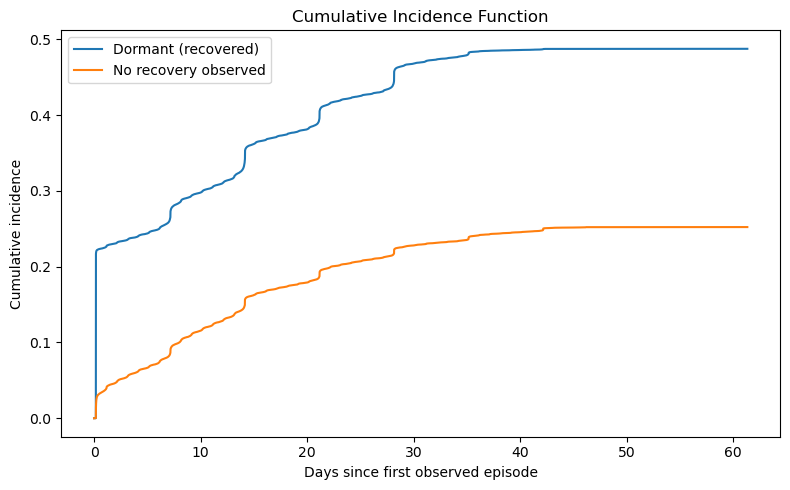

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
for event, label in [(1, "Dormant (recovered)"), (2, "No recovery observed")]:
    ajf = AalenJohansenFitter()
    ajf.fit(df["time_to_dormancy_onset"], df["competing_event"], event_of_interest=event)
    cif = ajf.cumulative_density_
    ax.plot(cif.index, cif.iloc[:, 0], label=label)
ax.set_xlabel("Days since first observed episode")
ax.set_ylabel("Cumulative incidence")
ax.legend()
ax.set_title("Cumulative Incidence Function")
plt.tight_layout()
plt.show()

## Ablation 2: why competing risks matters

A standard Cox model treats *any* exit from observation — dormant-then-recovered or genuinely gone — as the same "churn" event. That's a real problem here: **66.2% of all "exit" events in this dataset are actually recoveries.** A model that isolates the true departure hazard (treating recovery as censored, not as the event) fits meaningfully better.

In [3]:
ablation2 = m3["ablation2"]
print(f"Standard Cox C-index: {ablation2['standard_cox_cindex']:.3f}")
print(f"Competing-risks-aware Cox C-index: {ablation2['competing_risks_cindex']:.3f}")
print(f"Fraction of 'exit' events that are actually recoveries: {ablation2['fraction_of_events_that_are_recoveries']:.1%}")

Standard Cox C-index: 0.655
Competing-risks-aware Cox C-index: 0.691
Fraction of 'exit' events that are actually recoveries: 66.2%


## Platform action matrix

Combining a dormancy classifier and a departure classifier (both trained on day-14 features, matching Module 1's design) into a recommended platform action per creator.

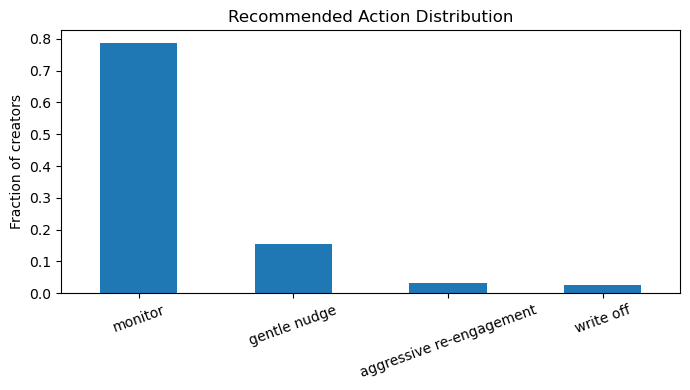

monitor                     0.787592
gentle nudge                0.154680
aggressive re-engagement    0.031076
write off                   0.026652
dtype: float64

In [4]:
action_dist = pd.Series(m3["action_matrix"]["action_distribution"]).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
action_dist.plot(kind="bar", ax=ax)
ax.set_ylabel("Fraction of creators")
ax.set_title("Recommended Action Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
action_dist

## Key Findings

- **Of creators who go silent for 14+ days, 66% eventually return.** A standard churn model would count all of them as gone.
- **66.2% of all "exit" events are actually recoveries** — the clearest, most quotable finding in the whole project. Treating dormancy as churn substantially overstates the departure problem.
- **Monetized creators recover at a meaningfully higher rate** (72.1% vs. 65.9%) — consistent with, though not proof of, monetization acting as a retention signal even though Module 2 didn't find a significant *causal* posting-behavior effect.
- The competing-risks-aware Cox model outperforms the standard one (0.691 vs. 0.655 C-index) — evidence that properly separating recovery from departure isn't just conceptually right, it's measurably better.
- ~79% of creators fall into "monitor" under the platform action matrix — most creators don't need intervention; the action framework's value is in flagging the ~5% split between "aggressive re-engagement" and "write off."